In [1]:
from datasets import load_dataset
import numpy as np
import pandas as pd


o:\enset\hello\Agentic AI\tps\Use-Case-Sentiment-Analysis\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ds = load_dataset('imdb')

o:\enset\hello\Agentic AI\tps\Use-Case-Sentiment-Analysis\.venv\lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ASUS\.cache\huggingface\hub\datasets--imdb. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating unsupervised split: 100%|██████████| 50000/50000 [00:00<00:00, 582451.62 examples/s]


In [3]:
ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [4]:
train_df = ds['train'].to_pandas();

In [5]:
train_df.sample(5)

,text,label
20352,"Now all the kids and teenagers of Springwood, ...",1
3937,Underneath the dense green glop of computer gr...,0
8519,Semana Santa is jaw-droppingly bad. It's so wr...,0
5339,This production never really got off the groun...,0
21772,Several young Iranian women dress as boys and ...,1


In [6]:
train_df['label'].value_counts()

label
0    12500
1    12500
Name: count, dtype: int64

In [7]:
train_df['sentiment'] = np.where(train_df['label'] == 1, 'positive', 'negative')

In [8]:
train_df.sentiment.value_counts()

sentiment
negative    12500
positive    12500
Name: count, dtype: int64

<Axes: >

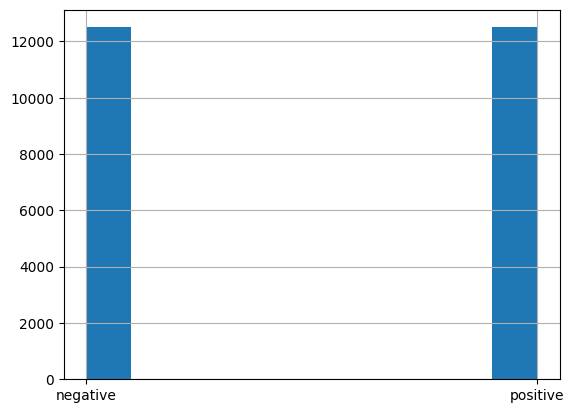

In [9]:
train_df.sentiment.hist()

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
examples_df , gold_examples_df = train_test_split(train_df, test_size=0.2, random_state=123)

In [12]:
examples_df.shape, gold_examples_df.shape

((20000, 3), (5000, 3))

In [13]:
columns = ['text', 'sentiment']
gold_examples = (gold_examples_df[columns]
                 .sample(10,random_state=34)
                 .to_json(orient='records')
                 )


In [14]:
import json

In [15]:
json.loads(gold_examples)[0]

{'text': '"A Guy Thing" may not be a classic, but it sure is a good, funny comedy. The plot focuses on Paul (Jason Lee), who wakes up the morning after his bachelor party with no memory and Becky (Julia Stiles) lying naked in his bed. Before he can figure out what happened, he rushes Becky out of his apartment because his fiance Karen (Selma Blair) is coming. After that, as you could imagine, chaos ensues.<br /><br />Almost every single scene in "A Guy Thing" delivers loud laughs. The funniest moments come from when Paul imagines what could happen if he tells Karen. Selma Blair is a truly talented comedian, and the worst thing about this film is that she goes underused. Although, she turns out to be more funny than Stiles\' character, who actually isn\'t that interesting. Of course, not every comedy is perfect.<br /><br />As I said, "A Guy Thing" is no classic, but it\'s not bad either, 7/10.',
 'sentiment': 'positive'}

In [16]:
user_prompt_template = """```{movie_review}```""" 

In [17]:
zero_shot_prompt_system = """
Classify the sentiment of movie reviews presented in the input as either positive or negative.
Movie reviews will be delimited by triple backticks ``` in the input
Answer only as 'positive' or 'negative'
Do not explain your answer, just give the label.
"""

In [18]:
zero_shot_prompt = [{"role": 'system', "content": zero_shot_prompt_system}] 

In [19]:
few_shot_prompt_system = """
Classify the sentiment of movie reviews presented in the input as either positive or negative.
Movie reviews will be delimited by triple backticks ``` in the input
Answer only as 'positive' or 'negative'
Do not explain your answer, just give the label.
"""

In [20]:
positive_reviews = examples_df[examples_df['sentiment'] == 'positive']
negative_reviews = examples_df[examples_df['sentiment'] == 'negative']

In [21]:
negative_reviews.shape, positive_reviews.shape


((10037, 3), (9963, 3))

In [22]:
positive_examples =  (positive_reviews[columns]
                      .sample(5)
                      .to_json(orient='records')
                      )

In [23]:
negative_examples =  (negative_reviews[columns]
                      .sample(5)
                      .to_json(orient='records')
                      )

In [24]:
json.loads(positive_examples)

[{'text': "This has to be one of the best comedies on the television at the moment. It takes the sugary-sweet idea of a show revolving around a close family and turns it into a quite realistic yet funny depiction of a typical family complete with sibling and parent spats, brat brothers, over-protective fathers and bimbo sisters. I'm almost surprised it's Disney!<br /><br />To its credit, '8 Simple Rules' knows it's a comedy and doesn't try to be more. Too many shows (eg, 'Sister, Sister' and 'Lizzie McGuire') think just because its lead characters are now teenagers then they should tackle social issues and end up losing their humour by being too hard-hitting. This is a trap '8 Simple Rules' has avoided; it does tackle some issues (such as being the school outcast) but it has fun while doing so. In fact the only time it has really been serious was understandably when it sensitively handled the tragic death of John Ritter and his character.<br /><br />And I think, although John Ritter wi

In [25]:
json.loads(negative_examples)

[{'text': "This film was the most longest film and the record breaking film for sure It had 30 actors After JAANI DUSHMAN(2002) i guess no one had the guts to do something like that<br /><br />The film as the title suggests is based on the Kargil war but the problem is there are too many characters and the romantic subplots and the songs of many characters are boring<br /><br />Even there are too many cinematic liberties like killing people with knifes, wonder which soldier does that?<br /><br />Direction by JP Dutta pales front of BORDER Music is okay<br /><br />Amongst the huge cast Ajay Devgan stands tall, Saif is very good in his part and also it's his first film with kareena, Abhishek is likable Manoj Bajpai has his moments Sanju is wasted, Suneil is okay Akshaye Khanna does his part well rest are passable Rani is good, Esha is okay rest are passable",
  'sentiment': 'negative'},
 {'text': 'Wow You guys are way too nice!!!Corny,Corny,Corny That is how I feel about that film.It sta

In [26]:
ex = pd.concat([positive_reviews[columns].sample(5, random_state=34), negative_reviews[columns].sample(5, random_state=34)], axis=0)

In [27]:
ex

,text,sentiment
14351,I went to see Antone Fisher not knowing what t...,positive
13676,This is a very good movie. Do you want to know...,positive
21696,Several story lines are interwoven here around...,positive
14251,"""I moved out here to get away from this kind o...",positive
16203,"Another powerful chick flick. This time, it re...",positive
2786,Do we really need any more narcissistic garbag...,negative
991,"This movie is so awful, it is hard to find the...",negative
12145,I had high hopes for Troy and I am so bitterly...,negative
11534,If I could i would give ZERO stars for this on...,negative
8372,- A film crew is shooting a horror movie in an...,negative


In [28]:
examples = ex.sample(4*2, replace=False).to_json(orient='records')

In [29]:
json.loads(examples )

[{'text': "Another powerful chick flick. This time, it revolves around Diana Gusman who is always getting into fights at school. Instead of getting expelled, she takes her anger elsewhere, to the boxing ring. She trains to be a boxer and there she meets featherweight Adrian and begins to fall in love with him. This movie has a powerful message of taking your dreams and going with them even if someone doesn't believe in you (in this case, her dad doesn't believe in her). That alone makes the movie worth the price. Enjoy",
  'sentiment': 'positive'},
 {'text': '- A film crew is shooting a horror movie in an old, supposedly cursed house where over the years, seven people have mysteriously died. One of the crew finds an old book of spells and it looks like it would be perfect to use in some of the ritual scenes in their movie. It is reasoned that the spells in the book are better written than the script they are using. But as the book is read, the graveyard outside suddenly comes to life. 

In [30]:
def create_examples(dataset,n=4):
    positive_reviews = dataset[dataset['sentiment'] == 'positive']
    negative_reviews = dataset[dataset['sentiment'] == 'negative']
    
    examples_df = pd.concat([positive_reviews[columns].sample(n, random_state=34), negative_reviews[columns].sample(n, random_state=34)], axis=0)
    
    examples =  examples_df.sample(2*n, replace=False).to_json(orient='records')
    return examples

In [31]:
examples_df.shape


(20000, 3)

In [32]:
examples = create_examples(examples_df, n=7)

In [33]:

json.loads(examples )

[{'text': 'Swayze doesn\'t make a very convincing Alan Quatermain. Compared to Stewart Granger; which growing up was my ultimate hero in films like the 1952 "Scaramouche", the 1952 "Prisoner of Zenda" and the 1950 "King Solomon\'s Mines"; Patrick Swayze fails utterly. Even the portrayal of an older Alan Quatermain by Sean Connery in "League of Extraordinary Gentlemen" was very good in an otherwise big flop. Also Alison Doody lacks the grace of Deborah Kerr in the role of the leading lady, and last but not least the impressive Siriaque in the role of Umbopa makes it very hard for anyone to fill his (shoes)!!! For someone who was disappointed by Richard Chamberlain\'s 1985 version, I now highly recommend it if you can\'t get your hand on the granger version.',
  'sentiment': 'negative'},
 {'text': "I went to see Antone Fisher not knowing what to expect and was most pleasantly surprised. The acting job by Derek Luke was outstanding and the story line was excellent. Of course Denzel Washin

In [34]:
def create_prompt(system_message,examples,user_prompt_template):
    prompt = [{"role": 'system', "content": system_message}]
    for example in json.loads(examples):
        review = example['text']
        sentiment = example['sentiment']
        prompt.append({"role": 'user', "content": user_prompt_template.format(movie_review=review)})
        prompt.append({"role": 'assistant', "content": f"{sentiment}"})
    return prompt

In [35]:
few_shot_examples = create_examples(examples_df, n=2)

In [36]:
# %load (few_shot_examples)
[{"text":"This movie is so awful, it is hard to find the right words to describe it!<br \/><br \/>At first the story is so ridiculous.A narrow-minded human can write a better plot! The actors are boring and untalented, perhaps they were compelled to play in this cheesy Film.<br \/><br \/>The camera receptions of the National Forest are the only good in this whole movie. I should feel ashame, because I paid for this lousy Picture.<br \/><br \/>Hopefully nobody makes a sequel or make a similar film with such a worse storyline :-)","sentiment":"negative"},{"text":"Do we really need any more narcissistic garbage on the Baby Boomer generation? Technically, I am a Boomer, though at the time when all the \"idealistic youths\" of the '60s were reading Marx, burning their draft cards, and generally prolonging a war which destroyed tens of thousands of lives; I was still in grade school. But I remember them well, and 9 out of 10 were just moronic fools, who would believe anything as long as it was destructive.<br \/><br \/>This is just another excercise in self-importance from the kids who never really grew up.","sentiment":"negative"},{"text":"I went to see Antone Fisher not knowing what to expect and was most pleasantly surprised. The acting job by Derek Luke was outstanding and the story line was excellent. Of course Denzel Washington did his usual fine job of acting as well as directing. It makes you realized that people with mental problems CAN be helped and this movie is a perfect example of this. Don't miss this one.","sentiment":"positive"},{"text":"This is a very good movie. Do you want to know the real reasons why so many here are knocking this movie? I will tell you. In this movie, you have a black criminal who outwits a white professor. A black cop who tells the white professor he is wrong for defending the black criminal and the black cop turns out to be right, thus. \u0085making the white professor look stupid. It always comes down to race. This is an excellent movie. Pay no attention to the racist. If you can get over that there are characters who are played by blacks in this movie who outsmart the white characters, then you shouldn't have any problems enjoying this movie. I recommended everyone to go see this movie.","sentiment":"positive"}]

[{'text': 'This movie is so awful, it is hard to find the right words to describe it!<br \\/><br \\/>At first the story is so ridiculous.A narrow-minded human can write a better plot! The actors are boring and untalented, perhaps they were compelled to play in this cheesy Film.<br \\/><br \\/>The camera receptions of the National Forest are the only good in this whole movie. I should feel ashame, because I paid for this lousy Picture.<br \\/><br \\/>Hopefully nobody makes a sequel or make a similar film with such a worse storyline :-)',
  'sentiment': 'negative'},
 {'text': 'Do we really need any more narcissistic garbage on the Baby Boomer generation? Technically, I am a Boomer, though at the time when all the "idealistic youths" of the \'60s were reading Marx, burning their draft cards, and generally prolonging a war which destroyed tens of thousands of lives; I was still in grade school. But I remember them well, and 9 out of 10 were just moronic fools, who would believe anything as

In [37]:
few_shot_prompt = create_prompt(few_shot_prompt_system, few_shot_examples, user_prompt_template)

In [38]:
few_shot_prompt

[{'role': 'system',
  'content': "\nClassify the sentiment of movie reviews presented in the input as either positive or negative.\nMovie reviews will be delimited by triple backticks ``` in the input\nAnswer only as 'positive' or 'negative'\nDo not explain your answer, just give the label.\n"},
 {'role': 'user',
  'content': '```Do we really need any more narcissistic garbage on the Baby Boomer generation? Technically, I am a Boomer, though at the time when all the "idealistic youths" of the \'60s were reading Marx, burning their draft cards, and generally prolonging a war which destroyed tens of thousands of lives; I was still in grade school. But I remember them well, and 9 out of 10 were just moronic fools, who would believe anything as long as it was destructive.<br /><br />This is just another excercise in self-importance from the kids who never really grew up.```'},
 {'role': 'assistant', 'content': 'negative'},
 {'role': 'user',
  'content': '```This movie is so awful, it is ha

In [39]:
cot_few_shot_prompt_system = """
Classify the sentiment of movie reviews presented in the input as either positive or negative.
Movie reviews will be delimited by triple backticks ``` in the input
Answer only as 'positive' or 'negative'
Do not explain your answer, just give the label.

Instructions :
1. Carefully read the text of the review and think through the options for sentiment provided.
2. Consider the overall sentiment of the review and estimate the probability of the review being positive 

To reiterate, your answer should strictly only contain the label: positive or negative
"""

In [40]:
cot_few_shot_prompt = create_prompt(cot_few_shot_prompt_system, few_shot_examples, user_prompt_template)

In [41]:
cot_few_shot_prompt

[{'role': 'system',
  'content': "\nClassify the sentiment of movie reviews presented in the input as either positive or negative.\nMovie reviews will be delimited by triple backticks ``` in the input\nAnswer only as 'positive' or 'negative'\nDo not explain your answer, just give the label.\n\nInstructions :\n1. Carefully read the text of the review and think through the options for sentiment provided.\n2. Consider the overall sentiment of the review and estimate the probability of the review being positive \n\nTo reiterate, your answer should strictly only contain the label: positive or negative\n"},
 {'role': 'user',
  'content': '```Do we really need any more narcissistic garbage on the Baby Boomer generation? Technically, I am a Boomer, though at the time when all the "idealistic youths" of the \'60s were reading Marx, burning their draft cards, and generally prolonging a war which destroyed tens of thousands of lives; I was still in grade school. But I remember them well, and 9 ou

In [42]:
from sklearn.metrics import f1_score

In [ ]:
def evaluate_prompt(prompt, gold_examples, user_prompt_template,llm):
    predicted_sentiment = []
    ground_truth_sentiment = []
    for example in json.loads(gold_examples):
        review = example['text']
        sentiment = example['sentiment']
        user_input = [{"role": 'user', "content": user_prompt_template.format(movie_review=review)}]
        resp = llm.invoke(prompt + user_input)
        try:
            if 'negative' in resp.content.lower():
                predicted = 'negative'
            elif 'positive' in resp.content.lower():
                predicted = 'positive'
            else:
                predicted = 'unknown'
            predicted_sentiment.append(predicted)
            ground_truth_sentiment.append(sentiment)
            print(predicted, sentiment)
        except Exception as e:
            print(f"Error processing response: {e}")
            continue
        return f1_score(ground_truth_sentiment, predicted_sentiment, average='micro')

In [44]:
from dotenv.ipython import load_dotenv

In [50]:
load_dotenv(override=True)

True

In [51]:
from langchain_openai import ChatOpenAI

In [53]:
llm1 = ChatOpenAI(model="gpt-4o", temperature=0.0)

In [ ]:
evaluate_prompt(zero_shot_prompt, gold_examples, user_prompt_template,llm1)

1.0